# EDA MODIS MCD19A2 (MAIAC AOD) — Cali
## Análisis basado en metadata · 1 822 granules · tile h10v08 · 2020-2024

> **Nota:** Sin lector HDF4 disponible, el EDA trabaja sobre el manifiesto JSON  
> (fechas, tamaños, conteos). Para extraer valores AOD reales se requiere `pyhdf` / `gdal`.

| Fig | Contenido |
|-----|-----------|
| 1 | Granules por año |
| 2 | Granules por mes (apilado) |
| 3 | Heatmap año × mes |
| 4 | Días únicos con datos por mes |
| 5 | Distribución de tamaño de archivo |
| 6 | Tamaño acumulado de descarga |
| 7 | Cobertura por día del año |
| 8 | Distribución por día de la semana |
| 9 | Completitud de cobertura temporal |
| 10 | Disponibilidad día del año × año |
| 11 | Resumen estadístico (tabla) |
| 12 | Archivos por carpeta año/mes |


## 1. Imports y configuración

In [1]:
import json, warnings
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

%matplotlib inline
matplotlib.rcParams["figure.dpi"] = 120
warnings.filterwarnings("ignore")

# ── Rutas ──
ROOT          = Path().resolve().parent.parent   # ajusta según tu estructura
DATA_DIR      = ROOT / "data" / "modis" / "raw"
MANIFEST_PATH = ROOT / "data" / "manifests" / "manifest_modis_maiac.json"
OUT_DIR       = ROOT / "outputs" / "eda" / "modis"
OUT_DIR.mkdir(parents=True, exist_ok=True)
DPI = 150

def save(name):
    p = OUT_DIR / f"{name}.png"
    plt.savefig(p, dpi=DPI, bbox_inches="tight", facecolor="white")
    plt.show()
    plt.close()
    return p

print("Configuración lista ✅")


Configuración lista ✅


## 2. Carga del manifiesto y construcción del DataFrame

In [2]:
print("Cargando manifiesto MODIS...")
m        = json.loads(MANIFEST_PATH.read_text())
granules = m["granules"]

print(f"  Granules : {len(granules)}")
print(f"  Total GB : {m['total_gb']}")
print(f"  Tile     : {m['tile']}")

records = []
for g in granules:
    name  = g["name"]
    # MCD19A2.A2024001.h10v08.061.PID.hdf
    parts  = name.split(".")
    julian = parts[1]
    year, doy = int(julian[1:5]), int(julian[5:8])
    date = pd.Timestamp(year, 1, 1) + pd.Timedelta(days=doy - 1)
    records.append({
        "date"    : date,
        "year"    : year,
        "month"   : date.month,
        "doy"     : doy,
        "size_mb" : g["bytes"] / 1e6,
        "name"    : name,
    })

df = (
    pd.DataFrame(records)
    .sort_values("date")
    .reset_index(drop=True)
)
df["weekday"]   = df["date"].dt.dayofweek
df["year_month"] = df["date"].dt.to_period("M")

# Pivot año × mes (útil en varias figuras)
ym = df.groupby(["year", "month"]).size().unstack(fill_value=0)

print(f"Periodo      : {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Días únicos  : {df['date'].nunique()}")
print(f"Tamaño medio : {df['size_mb'].mean():.1f} MB/granule")
df.head()


Cargando manifiesto MODIS...
  Granules : 1822
  Total GB : 12.685
  Tile     : h10v08
Periodo      : 2020-01-01 → 2024-12-31
Días únicos  : 1822
Tamaño medio : 7.0 MB/granule


,date,year,month,doy,size_mb,name,weekday,year_month
0,2020-01-01,2020,1,1,9.610196,MCD19A2.A2020001.h10v08.061.2023132161306.hdf,2,2020-01
1,2020-01-02,2020,1,2,5.592436,MCD19A2.A2020002.h10v08.061.2023132165220.hdf,3,2020-01
2,2020-01-03,2020,1,3,11.182919,MCD19A2.A2020003.h10v08.061.2023132172137.hdf,4,2020-01
3,2020-01-04,2020,1,4,7.293804,MCD19A2.A2020004.h10v08.061.2023132175547.hdf,5,2020-01
4,2020-01-05,2020,1,5,10.234082,MCD19A2.A2020005.h10v08.061.2023132182643.hdf,6,2020-01


## Fig 1 — Granules por año

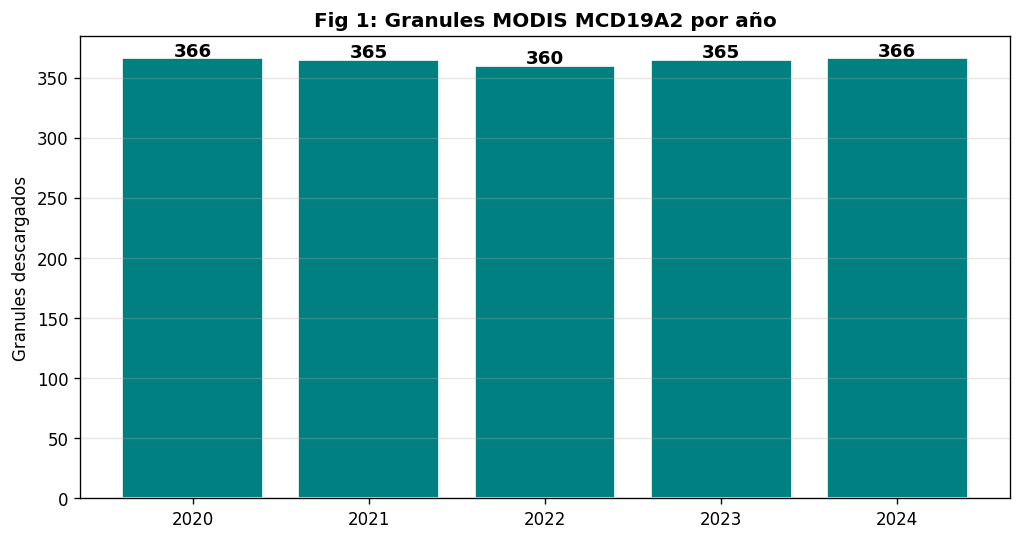

PosixPath('/home/nicolas/Escritorio/Academico/analitica_datos/carlos_andres_ferro/geovision-clip-airquality/outputs/eda/modis/01_granules_por_ano.png')

In [3]:
cnt = df["year"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(cnt.index.astype(str), cnt.values, color="teal", edgecolor="white")
for bar, v in zip(bars, cnt.values):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 2, str(v),
            ha="center", fontweight="bold", fontsize=11)
ax.set_ylabel("Granules descargados")
ax.grid(axis="y", alpha=0.3)
ax.set_title("Fig 1: Granules MODIS MCD19A2 por año", fontweight="bold")
save("01_granules_por_ano")


## Fig 2 — Granules por mes (apilado por año)

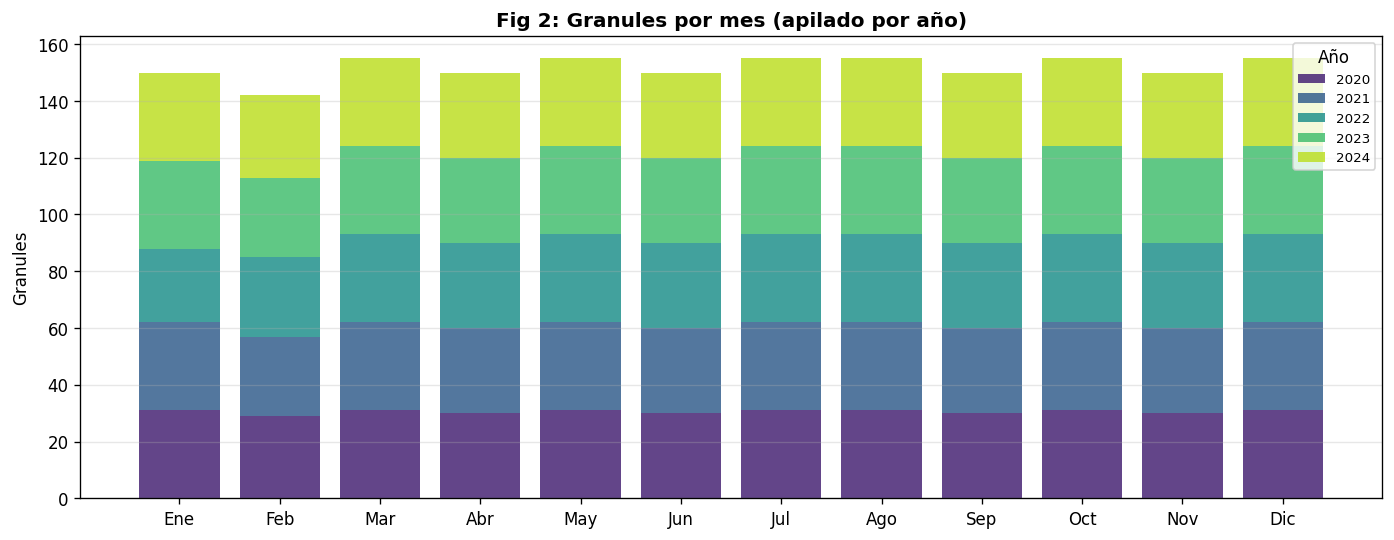

PosixPath('/home/nicolas/Escritorio/Academico/analitica_datos/carlos_andres_ferro/geovision-clip-airquality/outputs/eda/modis/02_granules_por_mes.png')

In [4]:
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(ym.index)))
bottom = np.zeros(12)

fig, ax = plt.subplots(figsize=(14, 5))
for yi, year in enumerate(ym.index):
    ax.bar(range(12), ym.loc[year].values, bottom=bottom,
           label=str(year), color=colors[yi], alpha=0.85)
    bottom += ym.loc[year].values

ax.set_xticks(range(12))
ax.set_xticklabels(["Ene","Feb","Mar","Abr","May","Jun","Jul","Ago","Sep","Oct","Nov","Dic"])
ax.set_ylabel("Granules")
ax.legend(title="Año", fontsize=8)
ax.set_title("Fig 2: Granules por mes (apilado por año)", fontweight="bold")
ax.grid(axis="y", alpha=0.3)
save("02_granules_por_mes")


## Fig 3 — Heatmap granules año × mes

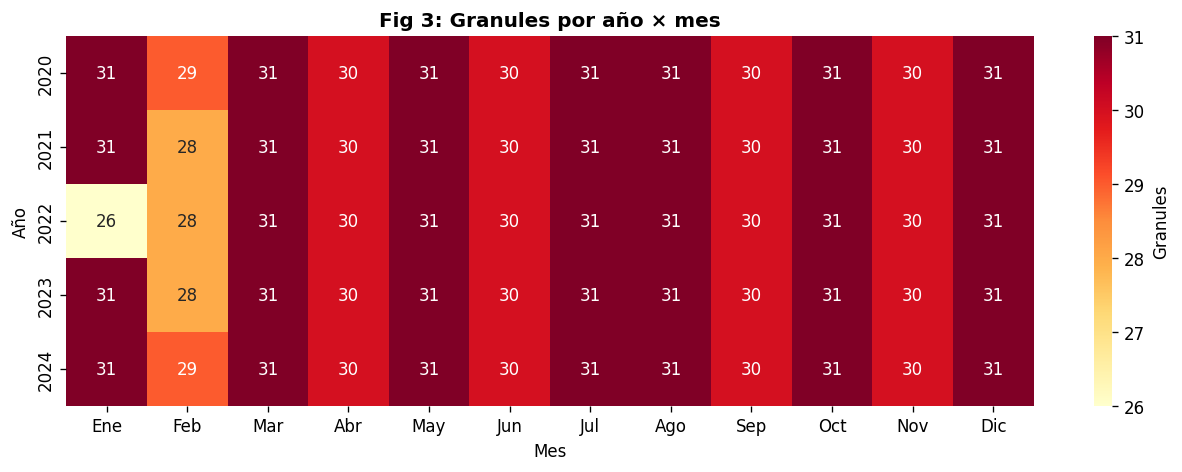

PosixPath('/home/nicolas/Escritorio/Academico/analitica_datos/carlos_andres_ferro/geovision-clip-airquality/outputs/eda/modis/03_heatmap_mensual.png')

In [5]:
fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(ym, annot=True, fmt="d", cmap="YlOrRd", ax=ax,
            cbar_kws={"label": "Granules"})
ax.set_title("Fig 3: Granules por año × mes", fontweight="bold")
ax.set_xlabel("Mes")
ax.set_ylabel("Año")
ax.set_xticklabels(["Ene","Feb","Mar","Abr","May","Jun","Jul","Ago","Sep","Oct","Nov","Dic"])
save("03_heatmap_mensual")


## Fig 4 — Días únicos con datos por mes

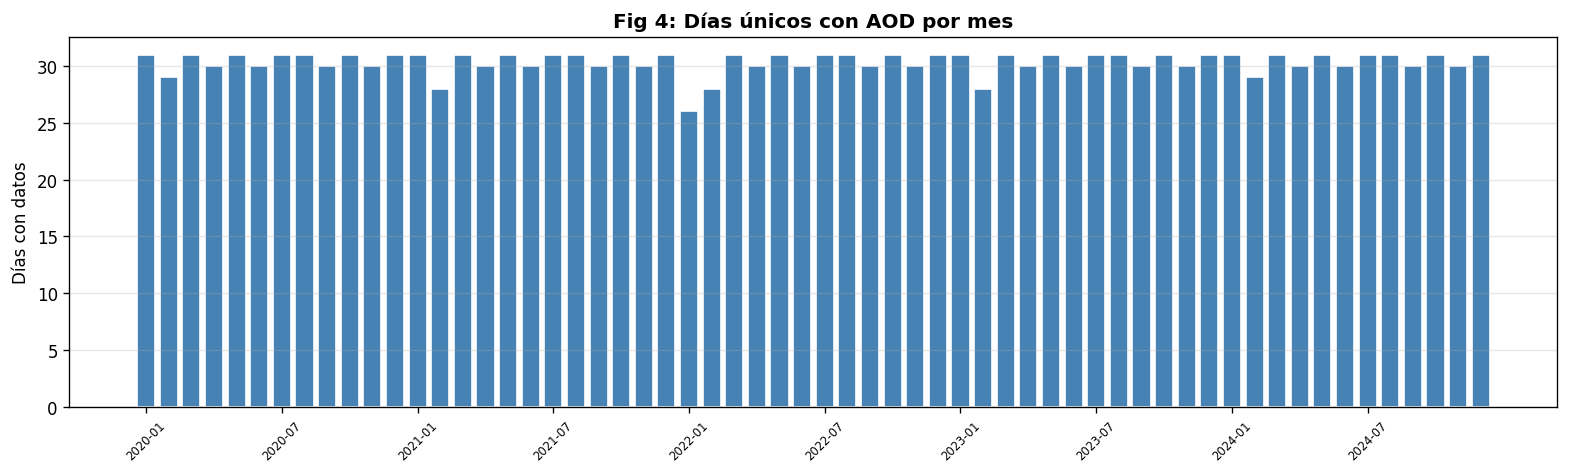

PosixPath('/home/nicolas/Escritorio/Academico/analitica_datos/carlos_andres_ferro/geovision-clip-airquality/outputs/eda/modis/04_dias_unicos_mes.png')

In [6]:
daily = df.groupby(df["date"].dt.to_period("M"))["date"].nunique()

fig, ax = plt.subplots(figsize=(16, 4))
ax.bar(range(len(daily)), daily.values, color="steelblue", edgecolor="white")
ax.set_xticks(range(0, len(daily), 6))
ax.set_xticklabels(
    [str(daily.index[i]) for i in range(0, len(daily), 6)],
    rotation=45, fontsize=7,
)
ax.set_ylabel("Días con datos")
ax.grid(axis="y", alpha=0.3)
ax.set_title("Fig 4: Días únicos con AOD por mes", fontweight="bold")
save("04_dias_unicos_mes")


## Fig 5 — Distribución de tamaño de archivo por año

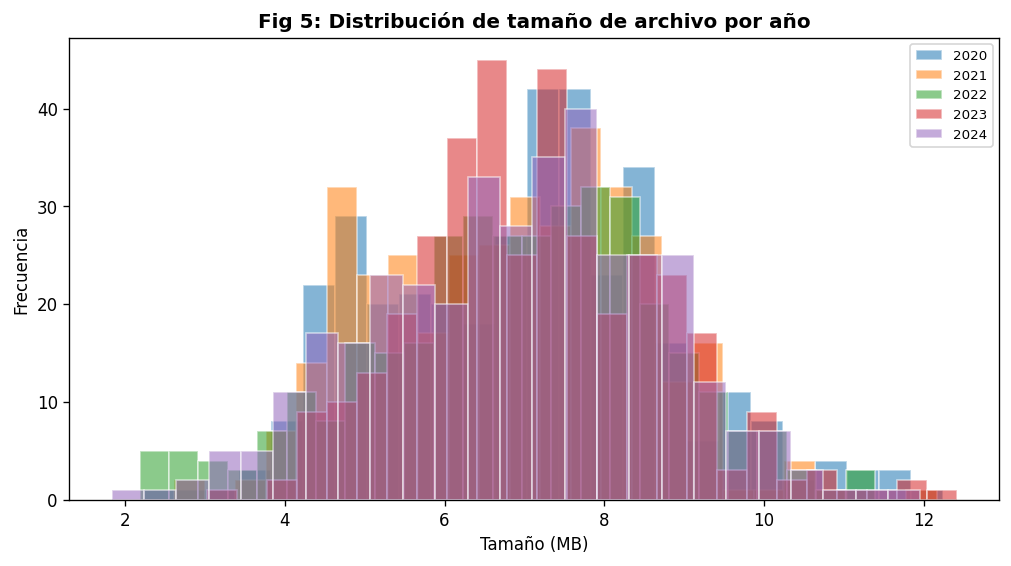

PosixPath('/home/nicolas/Escritorio/Academico/analitica_datos/carlos_andres_ferro/geovision-clip-airquality/outputs/eda/modis/05_tamano_archivos.png')

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
for year in sorted(df["year"].unique()):
    dy = df[df["year"] == year]["size_mb"]
    ax.hist(dy, bins=25, alpha=0.55, label=str(year), edgecolor="white")
ax.set_xlabel("Tamaño (MB)")
ax.set_ylabel("Frecuencia")
ax.legend(fontsize=8)
ax.set_title("Fig 5: Distribución de tamaño de archivo por año", fontweight="bold")
save("05_tamano_archivos")


## Fig 6 — Tamaño acumulado de descarga

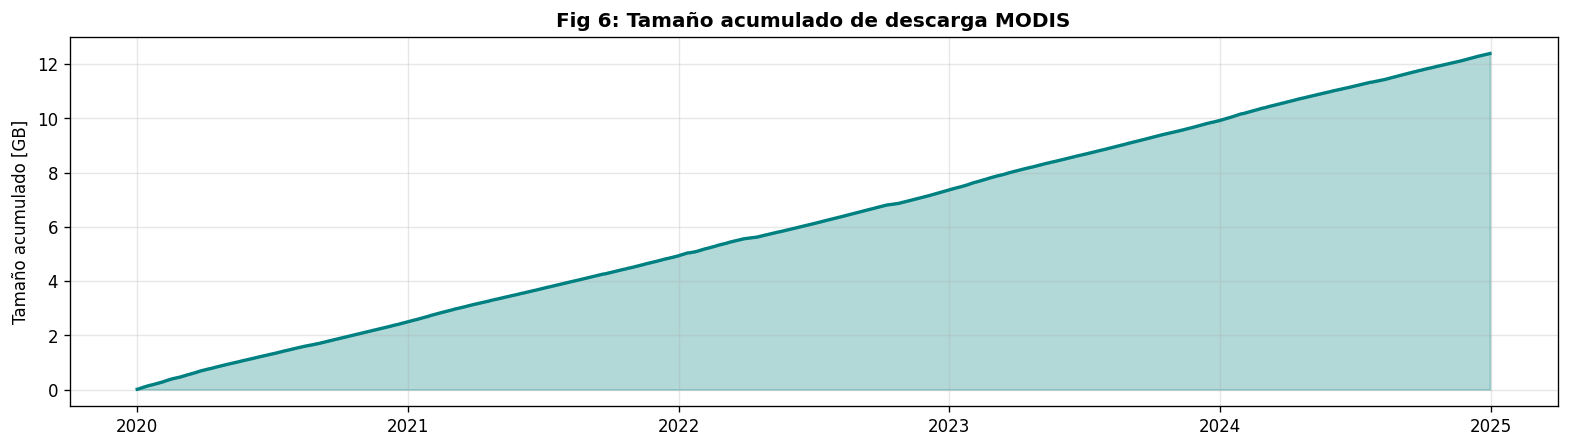

Descarga total: 12.39 GB


In [8]:
cumsum = df.set_index("date")["size_mb"].cumsum() / 1024   # MB → GB

fig, ax = plt.subplots(figsize=(16, 4))
ax.fill_between(cumsum.index, cumsum.values, alpha=0.3, color="teal")
ax.plot(cumsum.index, cumsum.values, lw=2, color="teal")
ax.set_ylabel("Tamaño acumulado [GB]")
ax.grid(alpha=0.3)
ax.set_title("Fig 6: Tamaño acumulado de descarga MODIS", fontweight="bold")
save("06_tamano_acumulado")
print(f"Descarga total: {cumsum.iloc[-1]:.2f} GB")


## Fig 7 — Cobertura por día del año (2020-2024 combinados)

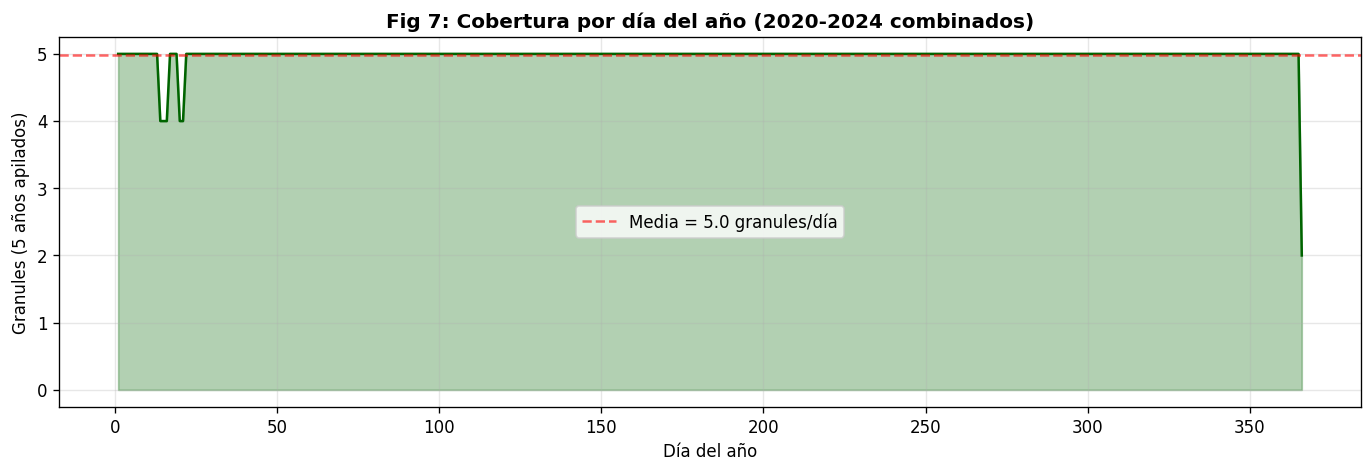

PosixPath('/home/nicolas/Escritorio/Academico/analitica_datos/carlos_andres_ferro/geovision-clip-airquality/outputs/eda/modis/07_cobertura_doy.png')

In [9]:
doy_counts = df.groupby("doy").size()

fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(doy_counts.index, doy_counts.values, alpha=0.3, color="darkgreen")
ax.plot(doy_counts.index, doy_counts.values, lw=1.5, color="darkgreen")
ax.axhline(doy_counts.mean(), color="red", ls="--", alpha=0.6,
           label=f"Media = {doy_counts.mean():.1f} granules/día")
ax.set_xlabel("Día del año")
ax.set_ylabel("Granules (5 años apilados)")
ax.legend()
ax.grid(alpha=0.3)
ax.set_title("Fig 7: Cobertura por día del año (2020-2024 combinados)", fontweight="bold")
save("07_cobertura_doy")


## Fig 8 — Distribución por día de la semana

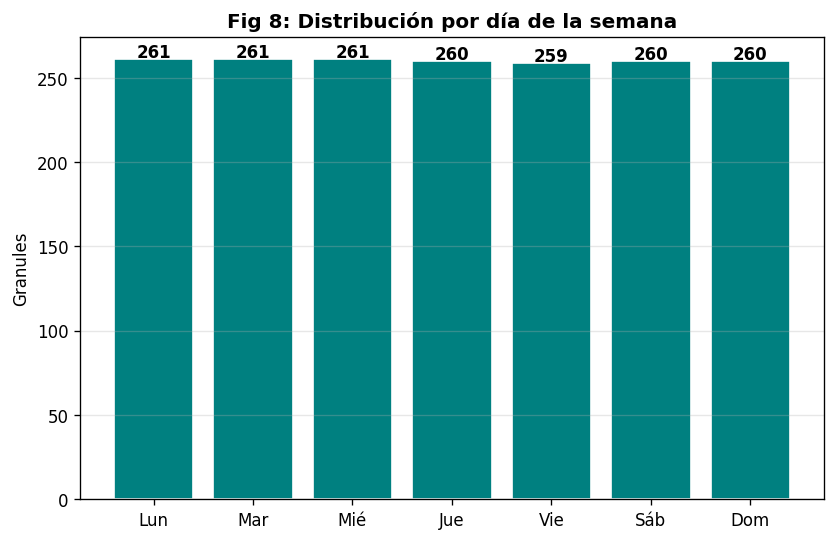

PosixPath('/home/nicolas/Escritorio/Academico/analitica_datos/carlos_andres_ferro/geovision-clip-airquality/outputs/eda/modis/08_dia_semana.png')

In [10]:
DIAS = ["Lun","Mar","Mié","Jue","Vie","Sáb","Dom"]
wd   = df["weekday"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar([DIAS[i] for i in wd.index], wd.values,
              color="teal", edgecolor="white")
for bar, v in zip(bars, wd.values):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 1, str(v),
            ha="center", fontweight="bold")
ax.set_ylabel("Granules")
ax.grid(axis="y", alpha=0.3)
ax.set_title("Fig 8: Distribución por día de la semana", fontweight="bold")
save("08_dia_semana")


## Fig 9 — Completitud de cobertura temporal

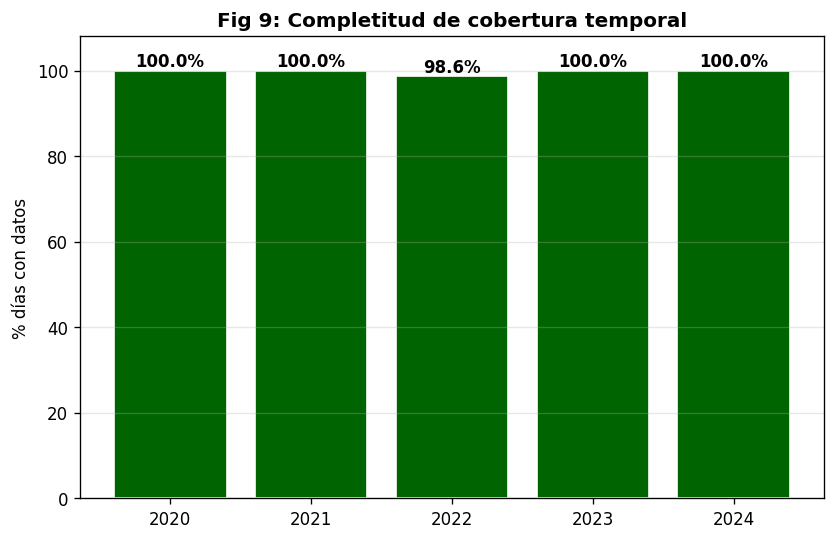

  2020: 100.0%  (366 / 366 días)
  2021: 100.0%  (365 / 365 días)
  2022: 98.6%  (360 / 365 días)
  2023: 100.0%  (365 / 365 días)
  2024: 100.0%  (366 / 366 días)


In [11]:
max_days = {2020: 366, 2021: 365, 2022: 365, 2023: 365, 2024: 366}
pct = {
    y: df[df["year"] == y]["date"].nunique() / max_days.get(y, 365) * 100
    for y in sorted(df["year"].unique())
}

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar([str(y) for y in pct], pct.values(),
              color="darkgreen", edgecolor="white")
for bar, (y, v) in zip(bars, pct.items()):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 1, f"{v:.1f}%",
            ha="center", fontweight="bold")
ax.set_ylabel("% días con datos")
ax.set_ylim(0, 108)
ax.grid(axis="y", alpha=0.3)
ax.set_title("Fig 9: Completitud de cobertura temporal", fontweight="bold")
save("09_completitud")

for y, v in pct.items():
    print(f"  {y}: {v:.1f}%  ({df[df['year']==y]['date'].nunique()} / {max_days[y]} días)")


## Fig 10 — Disponibilidad día del año × año

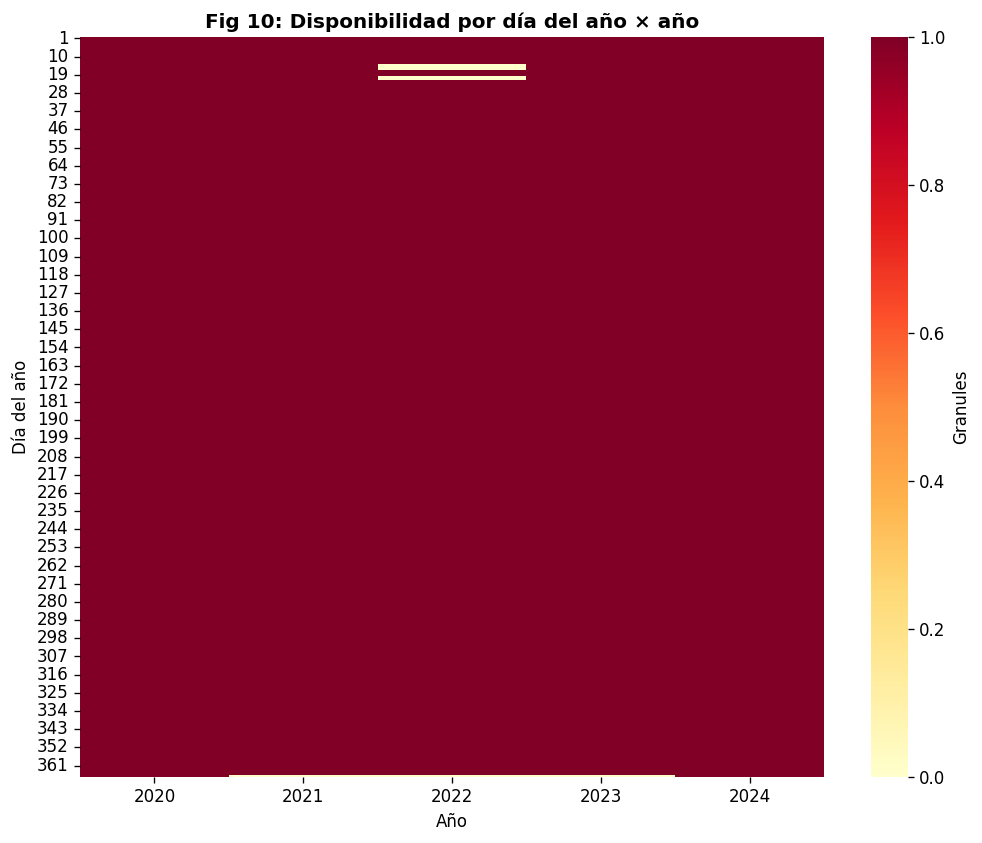

PosixPath('/home/nicolas/Escritorio/Academico/analitica_datos/carlos_andres_ferro/geovision-clip-airquality/outputs/eda/modis/10_doy_vs_ano.png')

In [12]:
pivot_doy = (
    df.pivot_table(index="doy", columns="year", values="date", aggfunc="count")
    .fillna(0)
)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(pivot_doy, cmap="YlOrRd", ax=ax, cbar_kws={"label": "Granules"})
ax.set_title("Fig 10: Disponibilidad por día del año × año", fontweight="bold")
ax.set_ylabel("Día del año")
ax.set_xlabel("Año")
save("10_doy_vs_ano")


## Fig 11 — Resumen estadístico (tabla)

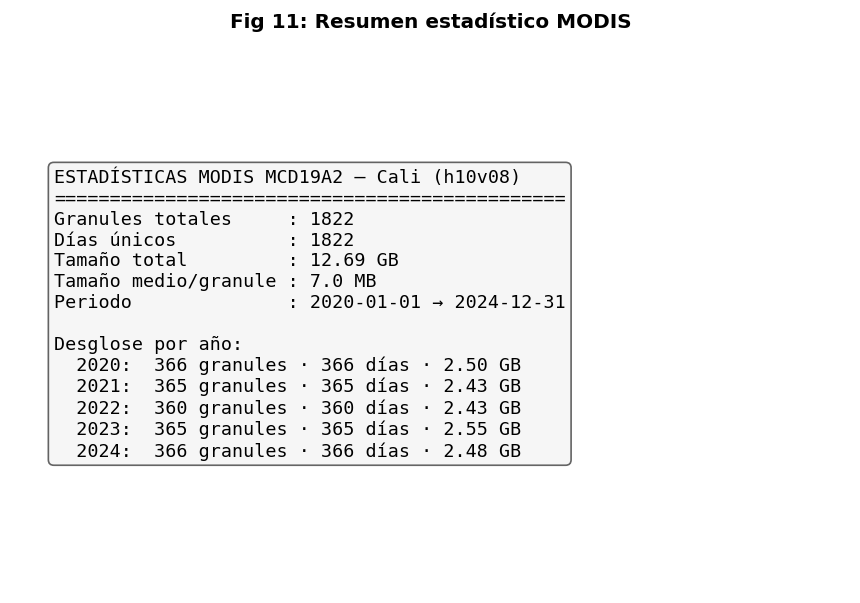

ESTADÍSTICAS MODIS MCD19A2 — Cali (h10v08)
Granules totales     : 1822
Días únicos          : 1822
Tamaño total         : 12.69 GB
Tamaño medio/granule : 7.0 MB
Periodo              : 2020-01-01 → 2024-12-31

Desglose por año:
  2020:  366 granules · 366 días · 2.50 GB
  2021:  365 granules · 365 días · 2.43 GB
  2022:  360 granules · 360 días · 2.43 GB
  2023:  365 granules · 365 días · 2.55 GB
  2024:  366 granules · 366 días · 2.48 GB


In [13]:
lineas = [
    "ESTADÍSTICAS MODIS MCD19A2 — Cali (h10v08)",
    "=" * 46,
    f"Granules totales     : {len(df)}",
    f"Días únicos          : {df['date'].nunique()}",
    f"Tamaño total         : {m['total_gb']:.2f} GB",
    f"Tamaño medio/granule : {df['size_mb'].mean():.1f} MB",
    f"Periodo              : {df['date'].min().date()} → {df['date'].max().date()}",
    "",
    "Desglose por año:",
]
for year in sorted(df["year"].unique()):
    dy = df[df["year"] == year]
    lineas.append(
        f"  {year}: {len(dy):4d} granules · {dy['date'].nunique():3d} días · "
        f"{dy['size_mb'].sum()/1024:.2f} GB"
    )
texto = "\n".join(lineas)

fig, ax = plt.subplots(figsize=(9, 6))
ax.axis("off")
ax.text(0.05, 0.5, texto, fontsize=11, fontfamily="monospace",
        va="center", transform=ax.transAxes,
        bbox=dict(boxstyle="round", facecolor="#f0f0f0", alpha=0.6))
ax.set_title("Fig 11: Resumen estadístico MODIS", fontweight="bold")
save("11_resumen_estadistico")
print(texto)


## Fig 12 — Archivos por carpeta año/mes

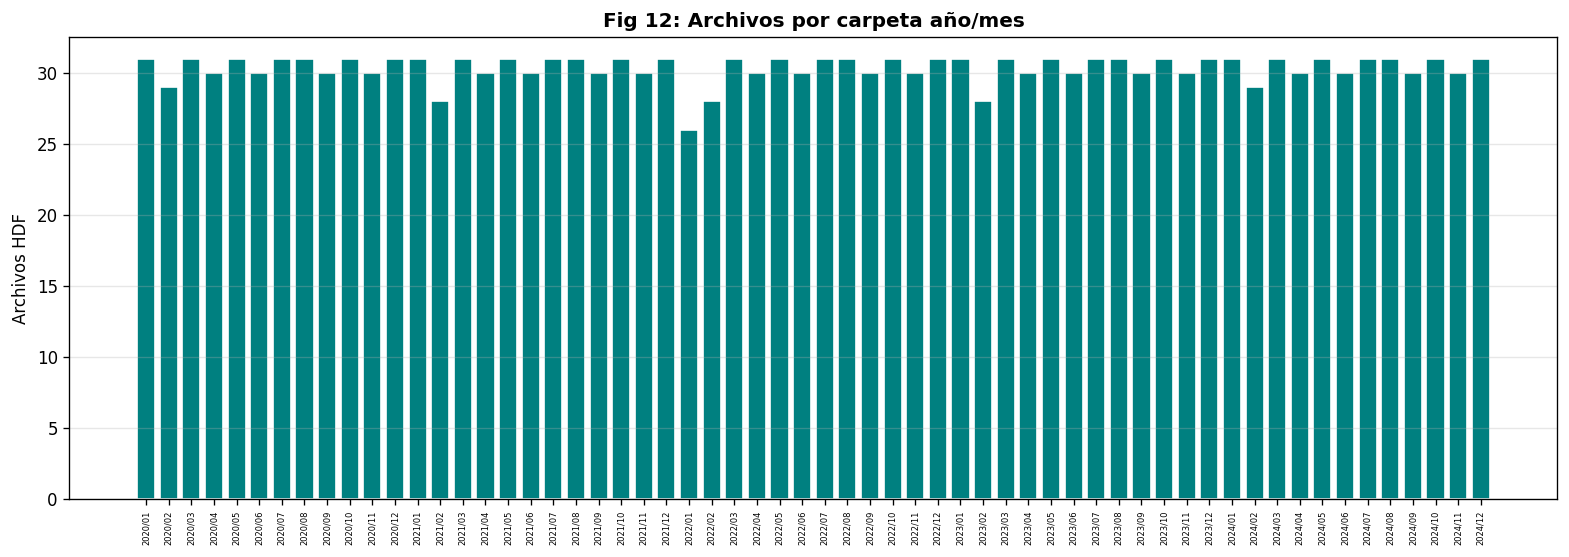

In [14]:
subdirs = defaultdict(int)
for f in DATA_DIR.rglob("*.hdf"):
    key = f"{f.parent.parent.name}/{f.parent.name}"
    subdirs[key] += 1

if subdirs:
    months_sorted = sorted(subdirs.keys())
    fig, ax = plt.subplots(figsize=(16, 5))
    ax.bar(months_sorted, [subdirs[k] for k in months_sorted],
           color="teal", edgecolor="white")
    ax.set_xticks(range(len(months_sorted)))
    ax.set_xticklabels(months_sorted, rotation=90, fontsize=5)
    ax.set_ylabel("Archivos HDF")
    ax.set_title("Fig 12: Archivos por carpeta año/mes", fontweight="bold")
    ax.grid(axis="y", alpha=0.3)
    save("12_estructura_carpetas")
else:
    print("⚠️  No se encontraron archivos .hdf en DATA_DIR.")
    print(f"   Ruta buscada: {DATA_DIR}")
    print("   La figura se omite; el resto del notebook es válido.")


## Resumen final

In [15]:
pngs = sorted(OUT_DIR.glob("*.png"))
print(f"✅ EDA MODIS completo")
print(f"   Directorio : {OUT_DIR}")
print(f"   Gráficas   : {len(pngs)}")
for p in pngs:
    print(f"   · {p.name}")
print()
print("NOTA: EDA basado en metadata JSON.")
print("Para valores AOD se requiere lector HDF4 (pyhdf / gdal).")


✅ EDA MODIS completo
   Directorio : /home/nicolas/Escritorio/Academico/analitica_datos/carlos_andres_ferro/geovision-clip-airquality/outputs/eda/modis
   Gráficas   : 12
   · 01_granules_por_ano.png
   · 02_granules_por_mes.png
   · 03_heatmap_mensual.png
   · 04_dias_unicos_mes.png
   · 05_tamano_archivos.png
   · 06_tamano_acumulado.png
   · 07_cobertura_doy.png
   · 08_dia_semana.png
   · 09_completitud.png
   · 10_doy_vs_ano.png
   · 11_resumen_estadistico.png
   · 12_estructura_carpetas.png

NOTA: EDA basado en metadata JSON.
Para valores AOD se requiere lector HDF4 (pyhdf / gdal).
